In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from sklearn import linear_model

In [2]:
data = pd.read_csv('YouTube_Video_Performance.csv')

Text(0, 0.5, 'VIEWS_K')

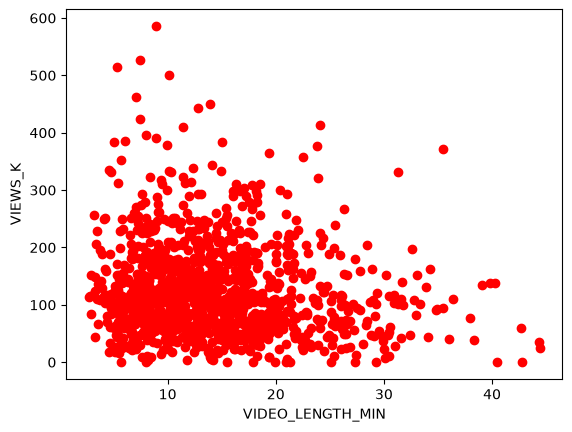

In [4]:
plt.scatter(data.VIDEO_LENGTH_MIN,data.VIEWS_K,color='red')
plt.xlabel("VIDEO_LENGTH_MIN")
plt.ylabel("VIEWS_K")

Text(0, 0.5, 'VIEWS_K')

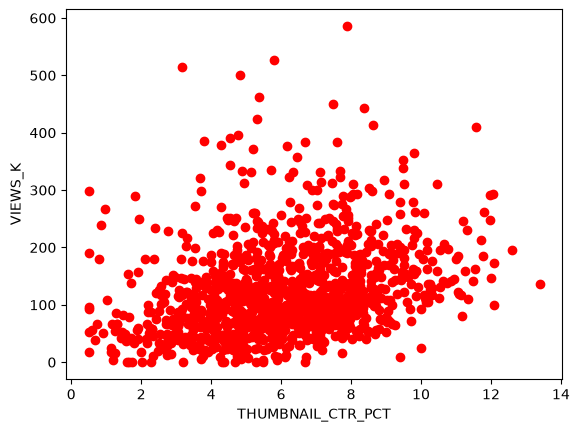

In [5]:
plt.scatter(data.THUMBNAIL_CTR_PCT,data.VIEWS_K,color='red')
plt.xlabel("THUMBNAIL_CTR_PCT")
plt.ylabel("VIEWS_K")

Text(0, 0.5, 'VIEWS_K')

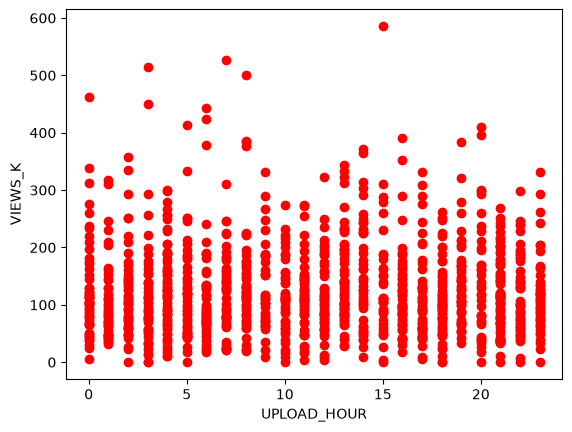

In [6]:
plt.scatter(data.UPLOAD_HOUR,data.VIEWS_K,color='red')
plt.xlabel("UPLOAD_HOUR")
plt.ylabel("VIEWS_K")

Text(0, 0.5, 'VIEWS_K')

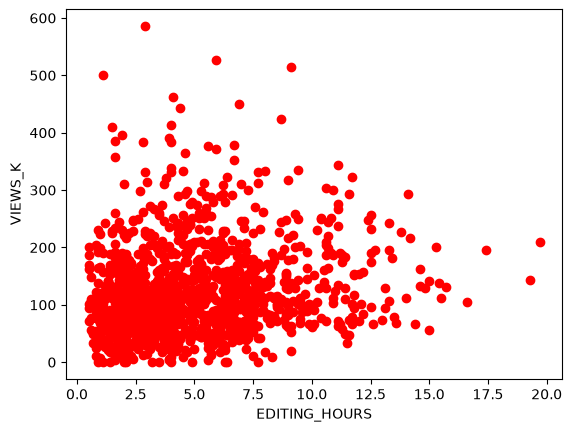

In [7]:
plt.scatter(data.EDITING_HOURS,data.VIEWS_K,color='red')
plt.xlabel("EDITING_HOURS")
plt.ylabel("VIEWS_K")

Text(0, 0.5, 'VIEWS_K')

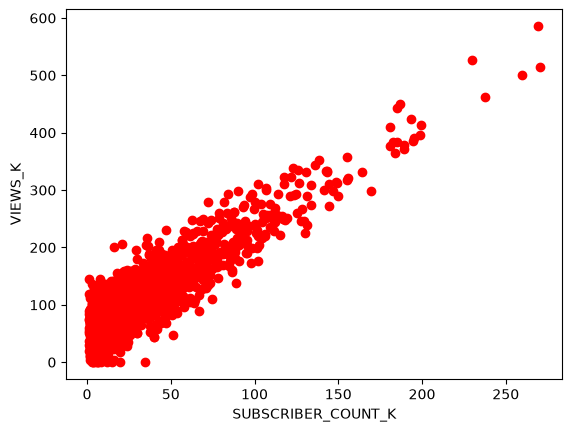

In [8]:
plt.scatter(data.SUBSCRIBER_COUNT_K,data.VIEWS_K,color='red')
plt.xlabel("SUBSCRIBER_COUNT_K")
plt.ylabel("VIEWS_K")

Text(0, 0.5, 'VIEWS_K')

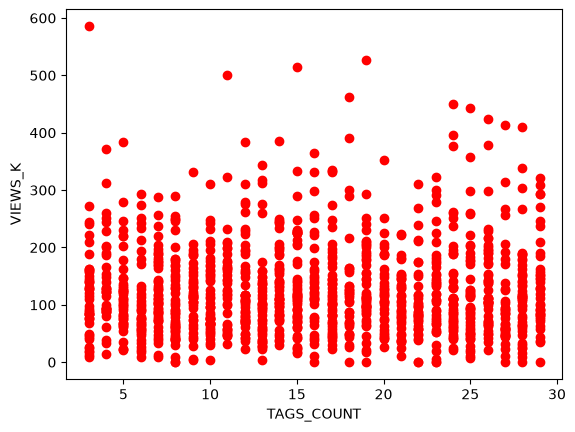

In [9]:
plt.scatter(data.TAGS_COUNT,data.VIEWS_K,color='red')
plt.xlabel("TAGS_COUNT")
plt.ylabel("VIEWS_K")

###### 1.SUBSCRIBER_COUNT_K   2.THUMBNAIL_CTR_PCT     3.VIDEO_LENGTH_MIN    4.EDITING_HOURS (same level as VIDEO_LENGTH_MIN)   and we have two noises: UPLOAD_HOUR,TAGS_COUNT

# simple linear regression with the strongest:

In [10]:
mask = np.random.rand(len(data)) < 0.8
train = data[mask]
test = data[~mask]

In [12]:
train_X = np.asanyarray(train[['SUBSCRIBER_COUNT_K']])
train_Y = np.asanyarray(train[['VIEWS_K']])

In [13]:
simpleregr = linear_model.LinearRegression()
simpleregr.fit(train_X,train_Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.83]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[52.45]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1204.01]


In [14]:
test_X = np.asanyarray(test[['SUBSCRIBER_COUNT_K']])
test_Y = np.asanyarray(test[['VIEWS_K']])

In [35]:
test_Y_OUT = simpleregr.predict(test_X)

In [ ]:
r2_mean = np.mean(test_Y)
ss_res = np.sum((test_Y - noise_test_out) ** 2)
ss_tot = np.sum((test_Y - r2_mean) ** 2)

r2 = 1 - (ss_res / ss_tot)
print(f"R2: {r2}")

R2: 0.7935850401986668


# multi linear regression

In [18]:
train_x = np.asanyarray(train[['SUBSCRIBER_COUNT_K','THUMBNAIL_CTR_PCT','VIDEO_LENGTH_MIN', 'EDITING_HOURS']])
train_y = np.asanyarray(train[['VIEWS_K']])

In [19]:
multiregr = linear_model.LinearRegression()
multiregr.fit(train_x,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[ 1.81, 8.5 ,-1.36, 3.21]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[4.73]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[1204.02, 216.66, 95.9 , 67.34]"


In [20]:
print(f"coefficients: {multiregr.coef_} intercept_ {multiregr.intercept_}")

coefficients: [[ 1.80730945  8.49937377 -1.35535454  3.21048111]] intercept_ [4.72571986]


In [21]:
test_x = np.asanyarray(test[['SUBSCRIBER_COUNT_K','THUMBNAIL_CTR_PCT','VIDEO_LENGTH_MIN', 'EDITING_HOURS']])
test_y = np.asanyarray(test[['VIEWS_K']])

In [23]:
test_out = multiregr.predict(test_x)

Text(0, 0.5, 'real data')

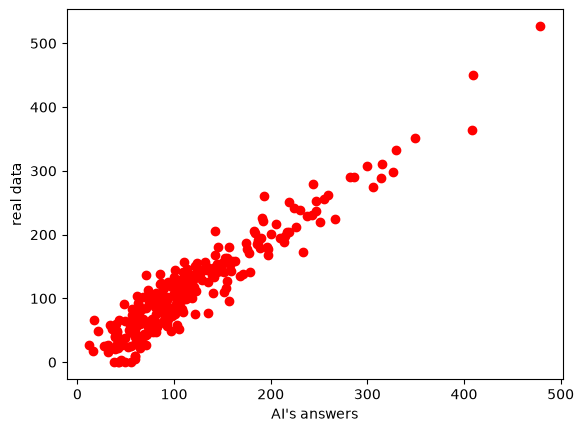

In [24]:
plt.scatter(test_out , test_y , color='red')
plt.xlabel("AI's answers")
plt.ylabel("real data")

In [27]:
absolute_error = np.abs(test_y - test_out)
mae = np.mean(absolute_error)

squared = np.square(test_y - test_out)
mse = np.mean(squared)

r2_mean = np.mean(test_y)
ss_res = np.sum((test_y - test_out) ** 2)
ss_tot = np.sum((test_y - r2_mean) ** 2)

r2 = 1 - (ss_res / ss_tot)


print(f"""mae : {mae}
mse: {mse}
R2: {r2}""")

mae : 19.766996880250225
mse: 609.4359272446923
R2: 0.8990718091682743


###### in the simple linear regression we had 0.7935850401986668 for the r2 but now we improved our model and we have 0.8990718091682743 for the r2 

# noise test

In [29]:
noise_x = np.asanyarray(train[['SUBSCRIBER_COUNT_K','THUMBNAIL_CTR_PCT','VIDEO_LENGTH_MIN', 'EDITING_HOURS','UPLOAD_HOUR', 'TAGS_COUNT']])
noise_y = np.asanyarray(train[['VIEWS_K']])

In [30]:
multiregtest = linear_model.LinearRegression()
multiregtest.fit(noise_x,noise_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 6)","[[ 1.81, 8.48,-1.35, 3.23, 0.11,-0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.47]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[1204.05, 241.71, 217.34, 210.65, 95.69, 67.19]"


In [33]:
noise_test_x = np.asanyarray(test[['SUBSCRIBER_COUNT_K','THUMBNAIL_CTR_PCT','VIDEO_LENGTH_MIN', 'EDITING_HOURS','UPLOAD_HOUR', 'TAGS_COUNT']])
noise_test_y = np.asanyarray(test[['VIEWS_K']])

In [34]:
noise_test_out = multiregtest.predict(noise_test_x)

In [36]:
r2_mean = np.mean(noise_test_y)
ss_res = np.sum((noise_test_y - noise_test_out) ** 2)
ss_tot = np.sum((noise_test_x - r2_mean) ** 2)

r2 = 1 - (ss_res / ss_tot)
print(f"R2: {r2}")

R2: 0.9905040182215981


###### somehow our r2 is now 0.9905040182215981, but why? i was think those are just noises but now they improve my model

### noise model answer vs multi reg model answer

In [38]:
subs = 90
thumbnail = 7
videolen = 10
editing = 10
upload = 8
tags = 15

noise_answer = multiregtest.intercept_ + multiregtest.coef_[0][0] * subs + multiregtest.coef_[0][1] * thumbnail + multiregtest.coef_[0][2] * videolen + multiregtest.coef_[0][3] * editing + multiregtest.coef_[0][4] * upload + multiregtest.coef_[0][5] * tags
multi_linear_answer = multiregtest.intercept_ + multiregtest.coef_[0][0] * subs + multiregtest.coef_[0][1] * thumbnail + multiregtest.coef_[0][2] * videolen + multiregtest.coef_[0][3] * editing

print(f"views(noise): {noise_answer[0]} views(multi linear): {multi_linear_answer[0]}")

views(noise): 245.1069519250265 views(multi linear): 244.25970653239196


###### views(noise): 245.1069519250265 views(multi linear): 244.25970653239196

###### i learned some data looks like noises but in reality u can use them for better r2, maybe they dont have any relations with the y but maybe they have some relations with other x's so they can improve our model